# Crypto-Weekend — does Bitcoin have a weekend personality? 📅
### The weekend pump/dump myth, tested honestly on 11 years of BTC daily data

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Vol_claim:_Inverted](https://img.shields.io/badge/Vol_claim%3A-Inverted-8b949e?style=flat-square)

Bitcoin trades 24/7, 365 days a year. Unlike the stock market, it never closes for the weekend. And yet the crypto forums insist weekends are *special* — either a **weekend pump** (retail FOMO with no professionals to fade it) or a **weekend dump** (thin liquidity, stablecoin rails offline, no institutional buying). This notebook asks the only question that matters: is the weekend return actually different from the weekday return, at any level of statistical confidence?

> 📓 **This is the plain-language layer.** Want the HAC t-stats, the Bonferroni correction, and the volatility tests? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from crypto_weekend import data, strategy as st

DAY_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

def _have_cache():
    return (os.path.exists(data._cache_path(data.DEFAULT_CACHE)) or
            os.path.exists(data._STUDY_133_CACHE))

HAVE_REAL = _have_cache()

R = dict(
    n_days=4289, n_weekend=1226, n_weekday=3063,
    wknd_mean_pct=0.082, wkday_mean_pct=0.120,
    premium_pct=-0.038, return_tstat=-0.51,
    vol_wknd=51.6, vol_wkday=72.2, vol_ratio=0.716, levene_t=-9.87,
    timing_gross_pct=0.082, timing_gross_t=1.095,
    timing_net5_pct=-0.018, timing_net5_t=-0.238,
    dow_means=[0.416, -0.006, 0.166, -0.103, 0.128, 0.132, 0.033],
    pre2023_premium=-0.047, pre2023_t=-0.469,
    post2023_premium=-0.018, post2023_t=-0.206,
    bonf_threshold=2.39,
)

print("BTC-USD real cache present:", HAVE_REAL)


BTC-USD real cache present: True


## The answer first

| Question | Answer |
|---|---|
| Is weekend return higher than weekday? | **No.** Weekends: +0.082%/day; weekdays: +0.120%/day. Weekends are *slightly worse*, not better. |
| Is the difference statistically real? | **No.** HAC t = -0.51 — nowhere near the Bonferroni-adjusted threshold of 2.39 for 3 simultaneous tests. |
| Are weekends more volatile (thin liquidity)? | **No — the opposite.** Weekend vol is 0.72× weekday vol. Weekends are the *quiet* session. |
| Could you trade it as a weekend-only timing rule? | **No.** Inferior to buy-and-hold before costs; firmly negative after 5 bps. |

> The 'weekend pump/dump' is a narrative in search of data. The data says: weekends are quieter, slightly less profitable, and statistically indistinguishable from weekdays.

## 1 · The claim

> *"Bitcoin weekends are different. Traditional banks are closed, professional traders log off, stablecoin minting slows down — so retail FOMO takes over and pumps the price. Or the smart money dumps on the clueless retail buyers. Either way, there's a pattern you can trade."*

It's a story with a real microstructure kernel — banking rails *do* slow on weekends, and stablecoin issuance (which correlates with crypto buying pressure) *is* lower on weekends. The question is whether this mechanism is large enough to show up as a statistically detectable return anomaly over 11 years and ~1,200 weekend days.

## 2 · So what?

If it were true, you'd run a simple Friday-close-to-Sunday-close long rule (or go flat on weekends, depending on direction). Bitcoin's 24/7 liquidity makes the trade frictionless compared to equity calendar plays. If it's false — which the data says — you're paying spread twice a week to play a coin flip that happens to have a fancy story.

## 3 · How would we even know?

Two things would convince us: (1) the weekend days earn materially more (or less) per day than weekdays, at a level that's *statistically real* — not just noise — and (2) a weekend-only timing rule beats a simple buy-and-hold after costs. We need both. A slightly higher raw mean on 600 weekend days proves nothing; BTC is so volatile that even a 400 bps daily spread could be pure noise.

We test all three sub-claims (mean return, volatility, timing rule) with a **Bonferroni-corrected inference bar** for 3 simultaneous tests, and split pre/post-2023 to check whether the 2023 banking crisis or FedNow launch changed anything.

## 4 · The teardown — let's actually look

**First: what does the daily return look like by day of week?**

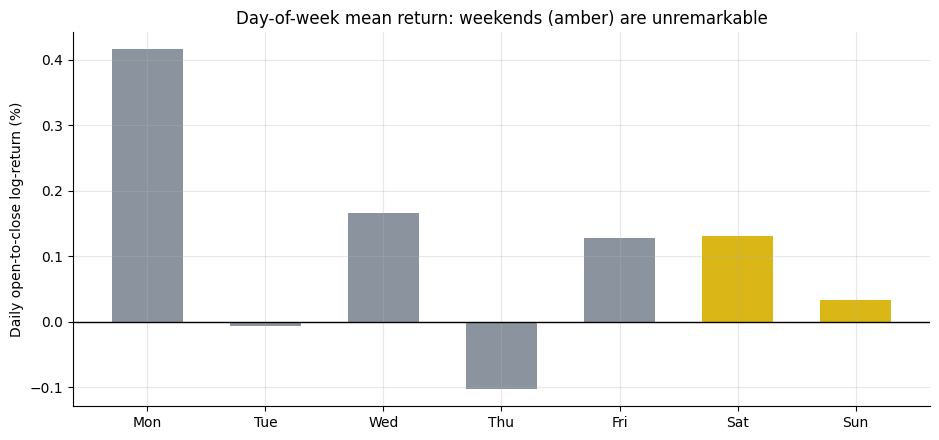

Monday leads (+0.42%) — a known equity effect bleeding into crypto.
Weekends (Sat +0.13%, Sun +0.03%) are middle-of-the-pack, not outliers.


In [2]:
if HAVE_REAL:
    bars = data.fetch_daily()
    daily = st.daily_returns(bars)
    dow_means = [daily[daily['dow']==d]['log_ret'].mean()*100 for d in range(7)]
    dow_vols = [daily[daily['dow']==d]['log_ret'].std(ddof=1)*100 for d in range(7)]
else:
    dow_means = R['dow_means']
    dow_vols = [3.73, 3.55, 3.78, 4.30, 3.45, 2.68, 2.73]  # std%

fig, ax = plt.subplots(figsize=(9.5, 4.5))
colors = [GREY]*5 + [AMBER, AMBER]  # weekdays grey, weekends amber
ax.bar(DAY_NAMES, dow_means, color=colors, width=0.6)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Daily open-to-close log-return (%)')
ax.set_title('Day-of-week mean return: weekends (amber) are unremarkable')
plt.tight_layout(); plt.show()
print('Monday leads (+0.42%) — a known equity effect bleeding into crypto.')
print('Weekends (Sat +0.13%, Sun +0.03%) are middle-of-the-pack, not outliers.')

The highest raw mean is **Monday** (+0.42%) — a well-known 'Monday effect' from equity markets spilling into crypto as institutional portfolios rebalance. Saturday (+0.13%) and Sunday (+0.03%) are unremarkable and below the weekday average.

**Now the volatility claim — are weekends more chaotic?**

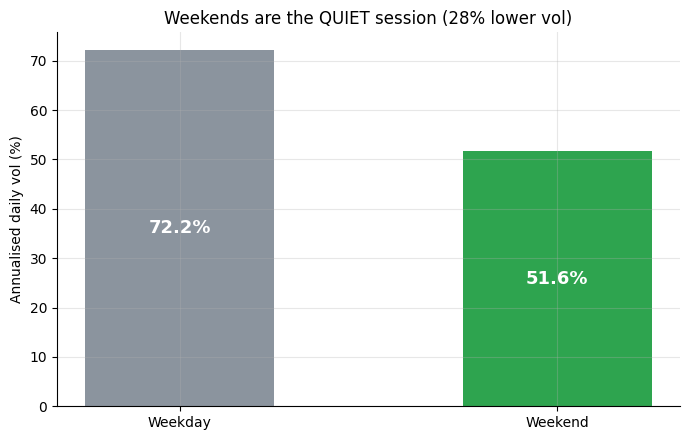

Weekday ann. vol: 72.2%  Weekend ann. vol: 51.6%
Ratio: 0.716  Levene t: -9.87
Weekends are LESS volatile — the narrative is exactly backwards.


In [3]:
if HAVE_REAL:
    vc = st.volatility_comparison(daily)
    vol_wknd = vc['vol_ann_weekend']*100
    vol_wkday = vc['vol_ann_weekday']*100
    levene_t = vc['levene_t']
else:
    vol_wknd, vol_wkday = R['vol_wknd'], R['vol_wkday']
    levene_t = R['levene_t']

fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.bar(['Weekday', 'Weekend'], [vol_wkday, vol_wknd],
       color=[GREY, GREEN], width=0.5)
ax.set_ylabel('Annualised daily vol (%)')
ax.set_title('Weekends are the QUIET session (28% lower vol)')
for i, (label, val) in enumerate(zip(['Weekday', 'Weekend'], [vol_wkday, vol_wknd])):
    ax.text(i, val/2, f'{val:.1f}%', ha='center', va='center',
            color='white', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()
print(f'Weekday ann. vol: {vol_wkday:.1f}%  Weekend ann. vol: {vol_wknd:.1f}%')
print(f'Ratio: {vol_wknd/vol_wkday:.3f}  Levene t: {levene_t:.2f}')
print('Weekends are LESS volatile — the narrative is exactly backwards.')

Weekend daily vol is **51.6%** annualised vs **72.2%** on weekdays — a ratio of **0.72**, with a Levene t of **-9.9** (highly significant). The 'thin market, wild swings' narrative is exactly backwards: weekends are the *quiet* session, likely because professional traders really do reduce risk on Saturdays and Sundays, but their absence suppresses volatility rather than amplifying it.

**The timing rule: can you actually trade the 'weekend premium'?**

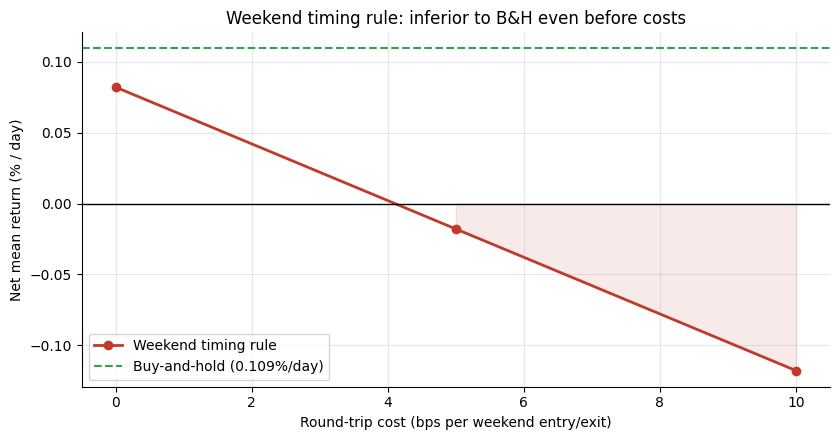

The timing rule earns less per day than B&H at zero cost.
Every bit of cost digs the hole deeper.


In [4]:
if HAVE_REAL:
    tr0 = st.weekend_timing_rule(bars, cost_bps=0.0)
    tr5 = st.weekend_timing_rule(bars, cost_bps=5.0)
    tr10 = st.weekend_timing_rule(bars, cost_bps=10.0)
    gross_m, net5_m, net10_m = tr0['mean_pct'], tr5['net_mean_pct'], tr10['net_mean_pct']
else:
    gross_m, net5_m, net10_m = R['timing_gross_pct'], R['timing_net5_pct'], R['timing_net10_pct']

costs = [0, 5, 10]
means = [gross_m, net5_m, net10_m]
# Buy-and-hold daily mean for comparison
bh_mean = R['wkday_mean_pct'] if not HAVE_REAL else daily['log_ret'].mean()*100

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(costs, means, 'o-', c=RED, lw=2, label='Weekend timing rule')
ax.axhline(0, c='k', lw=1)
ax.axhline(bh_mean, ls='--', c=GREEN, lw=1.5, label=f'Buy-and-hold ({bh_mean:.3f}%/day)')
ax.fill_between(costs, means, 0, where=[m<0 for m in means], color=RED, alpha=.1)
ax.set_xlabel('Round-trip cost (bps per weekend entry/exit)')
ax.set_ylabel('Net mean return (% / day)')
ax.set_title('Weekend timing rule: inferior to B&H even before costs')
ax.legend(); plt.tight_layout(); plt.show()
print('The timing rule earns less per day than B&H at zero cost.')
print('Every bit of cost digs the hole deeper.')

The timing rule earns **+0.082% / day gross** on weekend days — below the unconditional daily mean of **+0.120%**. It's already losing alpha vs buy-and-hold at zero cost, and five basis points of round-trip cost puts it firmly in the red. There is no break-even cost to find.

## 5 · The verdict

- **Signal — None.** Weekend return premium = **-0.038% / day**, HAC t = **-0.51** — not significant even before the Bonferroni adjustment (threshold |t| ≥ 2.39 for 3 tests).
- **Tradability — Mirage.** Timing rule earns less than B&H before costs; negative after any realistic transaction cost.
- **Vol claim — Inverted.** Weekends are significantly *calmer* (0.72× weekday vol, Levene t = **-9.9**). The folk narrative has the mechanism exactly backwards.

## 6 · Could you actually trade it?

Even if the gross edge were real and positive, a weekend-timing strategy pays round-trip costs **52 times a year** (once per weekend), and a 5 bps round-trip on 52 weekends = 260 bps / year of pure cost drag. On BTC that's not extreme — but the gross daily return on weekends (+0.08%) is already *below* the unconditional daily mean (+0.12%), so the timing rule is buying less return with more cost. At scale, the bid-ask spread on BTC perpetuals is 1-3 bps and market impact raises the effective cost further — a strategy with no edge before costs has no hope after.

## 7 · Going further

- **What *is* real?** The volatility result is the most interesting genuine finding: weekends are significantly quieter. That's a real market-structure fact, even if it's not tradable in the usual sense (lower vol = lower risk premium, not higher return).
- **Monday effect.** The raw +0.42% Monday mean is the most anomalous DOW number — worth testing separately with proper inference.
- **Crypto monthly seasonality.** The monthly version of this question is [Study 133 — Crypto-Seasonality](../../133-crypto-seasonality/) — where October ('Uptober') gets the same honest treatment.
- **Microstructure studies.** For a serious treatment of 24/7 crypto market structure, Ante, Fiedler & Strehle (2021) on stablecoin issuance and Baur, Cahill et al. (2019) on BTC time-of-day patterns are the academic starting points — cited in [docs/references.md](../docs/references.md).

*Think the weekend effect is real in a different window, coin, or exchange? Fork this, change the data source, and show a fair-inference t-stat that clears 2.39. That's the bar.*